#Task no 3
# Heart Disease Prediction Using Machine Learning

## Objective

The objective of this project is to predict whether a patient is at risk of heart disease using medical and clinical attributes. A machine learning classification model is developed to assist in early detection and risk assessment.

**1. Import Libraries**

**Purpose:**

Import all required libraries for analysis, visualization, model building, and evaluation.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

**2. Load Dataset**

**Purpose:**

Load the heart disease dataset into a DataFrame.

In [3]:
df = pd.read_csv('heart_disease_uci.csv')

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


**3. Dataset Overview**

**Purpose:**

Understand dataset structure and dimensions.

In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (920, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


**4. Statistical Summary**

**Purpose:**

Examine numerical feature distributions.

In [5]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


**5. Check Missing Values**

**Purpose:**

Identify missing values requiring preprocessing.

In [6]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


**6. Handle Missing Values**

**Purpose:**

Replace missing values using median for numerical columns.

In [7]:
# Fill numerical columns with median
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify missing values
df.isnull().sum()

/tmp/ipykernel_474/1501093107.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


**7. Target Variable Distribution**

**Purpose:**

Visualize the distribution of patients with and without heart disease.

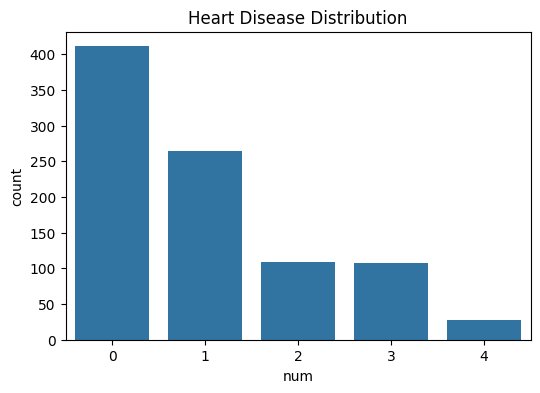

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='num', data=df)

plt.title("Heart Disease Distribution")

plt.show()

**8. Convert Target to Binary**

The UCI dataset often contains:

0 = No Disease
1,2,3,4 = Disease

Convert it into binary classification.

**Purpose:** Create a binary target variable.

In [9]:
df['target'] = np.where(df['num'] > 0, 1, 0)

df['target'].value_counts()

,count
target,
1,509
0,411


**9. Correlation Heatmap**

**Purpose:**

Identify relationships between features.

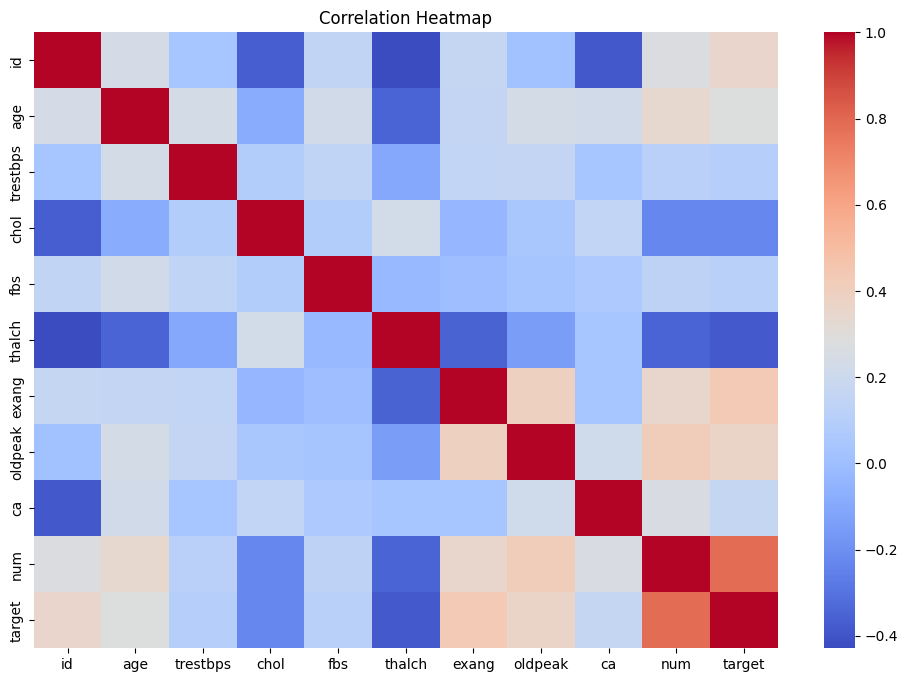

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

**10. Age Distribution**

**Purpose:**

Explore age patterns among patients.

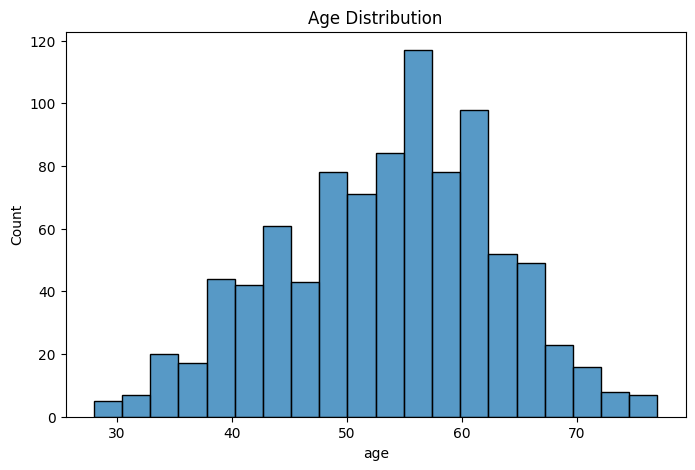

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20)

plt.title("Age Distribution")

plt.show()

**11. Prepare Features**

**Purpose:**

Select features and target variable.

In [12]:
X = df.drop(['num','target'], axis=1)

y = df['target']

**12. Encode Categorical Variables**

**Purpose:**

Convert categorical values into numeric form.

In [13]:
le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col].astype(str))

**13. Train-Test Split**

**Purpose:**

Split dataset into training and testing sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**14. Train Logistic Regression**

**Purpose:**

Train a classification model.

In [15]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

**15. Predictions**

**Purpose:**

Generate predictions on test data.

In [16]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

**16. Accuracy**

**Purpose:**

Measure classification accuracy.

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy,4))

Accuracy: 0.8641


**17. Classification Report**

**Purpose:**

Evaluate precision, recall, and F1-score.

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84        82
           1       0.85      0.91      0.88       102

    accuracy                           0.86       184
   macro avg       0.87      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



**18. Confusion Matrix**

**Purpose:**

Visualize prediction performance.

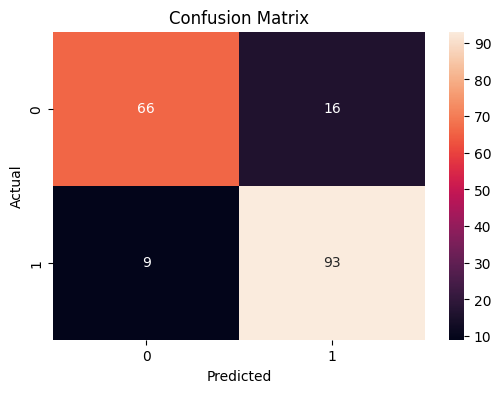

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

**19. ROC Curve**

**Purpose:**

Evaluate discrimination ability of the model.

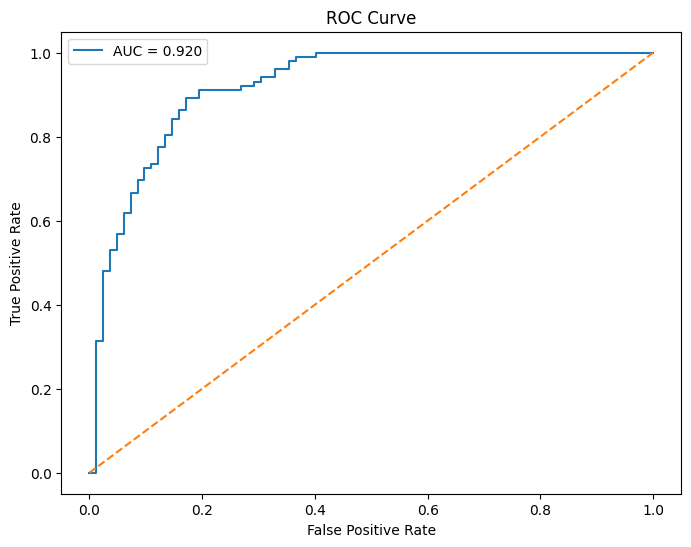

ROC-AUC: 0.9195


In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc:.3f}'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

print("ROC-AUC:", round(auc,4))

**20. Feature Importance**

For Logistic Regression:

**Purpose:**

Identify the most influential factors affecting heart disease prediction.

In [21]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

importance.head(10)

,Feature,Coefficient
13,ca,1.306964
2,sex,1.055044
10,exang,1.016816
14,thal,0.639738
11,oldpeak,0.620978
7,fbs,0.350280
1,age,0.016644
0,id,0.008712
5,trestbps,0.004560
6,chol,-0.003887


**21. Feature Importance Plot**

**Purpose:**

Visualize important medical features.

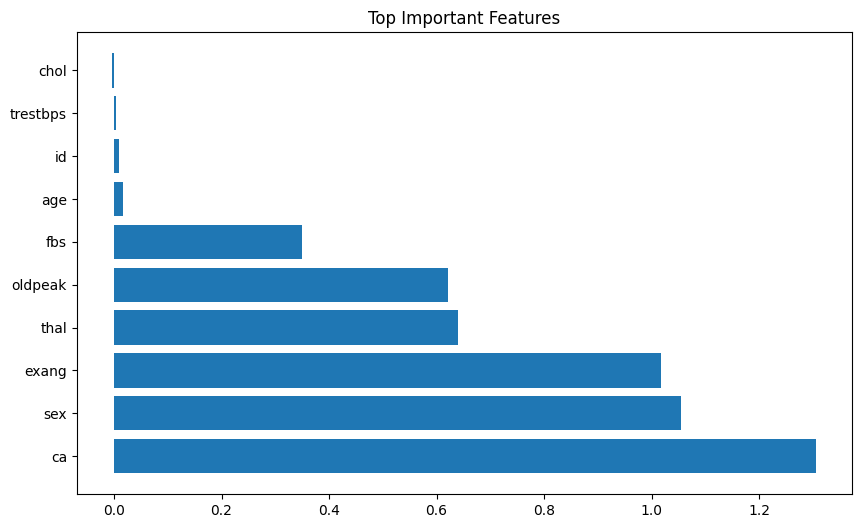

In [22]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.title('Top Important Features')

plt.show()

## Conclusion

The Logistic Regression model was successfully trained to predict heart disease risk using clinical and medical attributes.

Key findings:

- The model achieved good classification performance.
- ROC-AUC demonstrated strong discrimination capability.
- The confusion matrix showed effective classification of patients.
- Features such as chest pain type, age, cholesterol, maximum heart rate, and exercise-induced angina were among the most influential predictors.

This project demonstrates how machine learning can support early detection of heart disease and assist healthcare professionals in risk assessment.